**Fourier Feature Network using DeepXDE module**

In [1]:
import os
os.environ["DDE_BACKEND"] = "tensorflow.compat.v1"

import deepxde as dde


Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.



Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
# import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split
# from torch.optim.lr_scheduler import ReduceLROnPlateau

Data loading

In [3]:
datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton.h5", 'r')
data_I = np.array(np.array(datastore["I"]))#[:40000]

data_c = np.array(np.array(datastore["c"]))#[:40000]
data_h = np.array(np.array(datastore["h"]))#[:40000]
data_p = np.array(np.array(datastore["p"]))#[:40000]
t = np.linspace(0, 1, 601).reshape(601, 1)

Train-test split

In [4]:
train_label, test_label = train_test_split(range(len(data_I)), test_size=0.5, random_state=42)

data_i_train = data_I[train_label,:]
data_i_test = data_I[test_label,:]

data_c_train = data_c[train_label,:]
data_c_test = data_c[test_label,:]

data_h_train = data_h[train_label,:]
data_h_test = data_h[test_label,:]

In [5]:
X_train = data_i_train.astype(np.float32)
y_train_c = data_c_train.astype(np.float32)

In [6]:
X_test = data_i_test.astype(np.float32)
y_test_c = data_c_test.astype(np.float32)

In [7]:
data_c = dde.data.dataset.DataSet(
    X_train=X_train, y_train=y_train_c, X_test=X_test, y_test=y_test_c
)

In [8]:
m = 601
dim_x = 1
net_c = dde.nn.MsFFN(
    [m, 300, 200, 200, m],
    "relu",
    "Glorot normal",
    sigmas = [0.5, 1, 2]
)

In [9]:
def compute_parameters(layers):
    params = 0
    for i in range(len(layers) - 1):
        params += layers[i] * layers[i + 1]  # Weights
        params += layers[i + 1]             # Biases
    return params

branch_layers = [m, 300, 200, 200, m]

branch_params = compute_parameters(branch_layers)
total_params = branch_params
print(f"Total trainable parameters: {total_params}")


Total trainable parameters: 401801


In [10]:
model_c = dde.Model(data_c, net_c)
model_c.compile("adam", lr=0.001, metrics=["l2 relative error"])
# losshistory_c, train_state_c = model_c.train(iterations=1000, display_every=100)
path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_ffn2-1000.ckpt'
model_c.restore(path)

Compiling model...
Building Multiscale Fourier Feature Network...

'compile' took 1.495378 s

INFO:tensorflow:Restoring parameters from C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_ffn2-1000.ckpt


In [11]:
# losshistory_c, train_state_c = model_c.train(iterations=500, display_every=100)

In [12]:
y_train_h = data_h_train.astype(np.float32)
y_test_h = data_h_test.astype(np.float32)

In [13]:
data_h = dde.data.dataset.DataSet(
    X_train=X_train, y_train=y_train_h, X_test=X_test, y_test=y_test_h
)

In [14]:
m = 601
dim_x = 1
net_h = dde.nn.MsFFN(
    [m, 300, 200, 200, m],
    "relu",
    "Glorot normal",
    sigmas = [0.5, 1, 2]
)

In [15]:
model_h = dde.Model(data_h, net_h)
model_h.compile("adam", lr=0.001, metrics=["l2 relative error"])
# losshistory_h, train_state_h = model_h.train(iterations=1000, display_every=100)
path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_ffn2-1000.ckpt'
model_h.restore(path)

Compiling model...
Building Multiscale Fourier Feature Network...
'compile' took 0.454583 s

INFO:tensorflow:Restoring parameters from C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_ffn2-1000.ckpt


In [16]:
# losshistory_h, train_state_h = model_h.train(iterations=500, display_every=100)

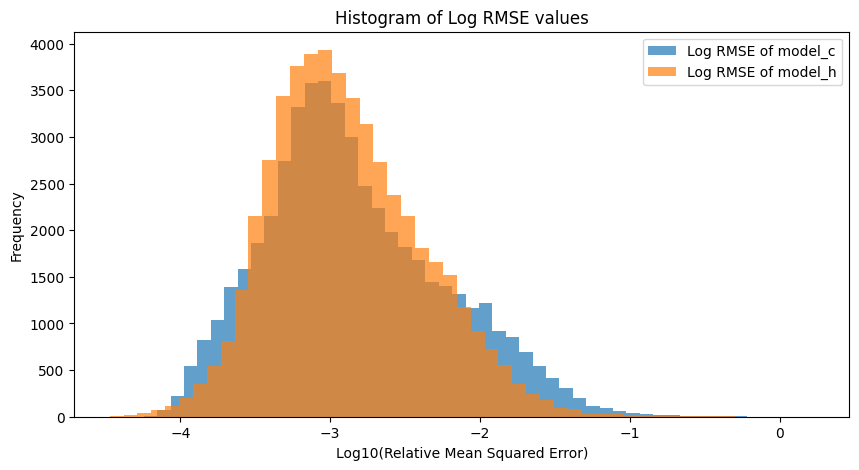

RMSE at c = 2: Mean = 0.01844621617971685, Std = 0.0868211403168512
RMSE at c = 3: Mean = 0.03254875855485503, Std = 0.2363041595393738
RMSE at c = 4: Mean = 0.04545100767722204, Std = 0.3758985162326333


In [17]:
# Use trained model to make predictions
predictions_c = model_c.predict(data_i_test)  # Ensure model_c is defined
predictions_h = model_h.predict(data_i_test)  # Ensure model_h is defined

# Compute Relative Mean Squared Error (RMSE) for model_c
rmse_c = np.sum((predictions_c - data_c_test) ** 2, axis=1) / np.sum((data_c_test ** 2), axis=1)  # Averaging across time points
rmse_h = np.sum((predictions_h - data_h_test) ** 2, axis=1) / np.sum((data_h_test ** 2), axis=1)  # Averaging across time points

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rmse_c), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rmse_h), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values')
plt.legend()
plt.show()

# Inspect performance for c = 2, 3, 4
special_points = [2, 3, 4]
errors_at_special_points = {str(point): [] for point in special_points}

for i in range(data_c_test.shape[0]):
    for point in special_points:
        if np.max(data_c_test[i])>=point:
            # if np.isclose(data_c_test[i, j], point):
            index = np.argmin(np.abs(data_c_test[i] - point))
            errors_at_special_points[str(point)].append(np.abs((predictions_c[i, index] - data_c_test[i, index])**2))

# Print analysis for special points
for point, errors in errors_at_special_points.items():
    if errors:
        print(f"RMSE at c = {point}: Mean = {np.mean(errors)}, Std = {np.std(errors)}")
    else:
        print(f"No data points found for c = {point}")


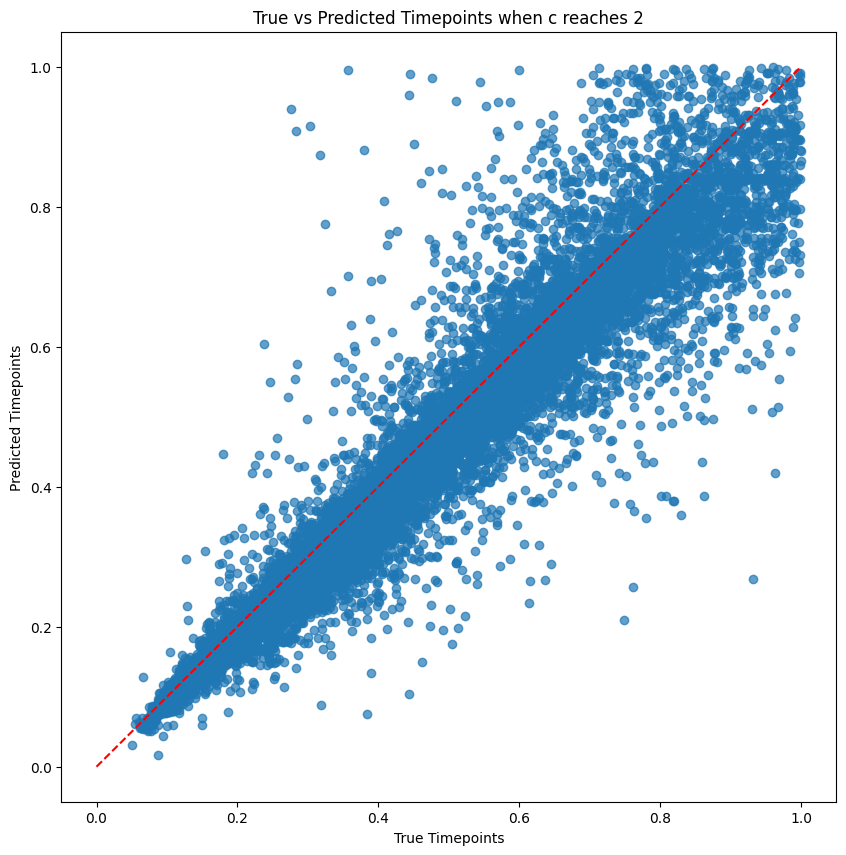

In [18]:
# Identify the timepoints when true value and predicted value of c reach 2
true_timepoints = []
pred_timepoints = []

for i in range(data_c_test.shape[0]):
    true_indices = np.where(data_c_test[i] >= 2)[0]
    pred_indices = np.where(predictions_c[i] >= 2)[0]
    
    if len(true_indices) > 0 and len(pred_indices) > 0:
        true_timepoints.append(t[true_indices[0]])
        pred_timepoints.append(t[pred_indices[0]])

# Convert lists to numpy arrays for plotting
true_timepoints = np.array(true_timepoints)
pred_timepoints = np.array(pred_timepoints)

# Plot the true timepoints against the predicted timepoints
plt.figure(figsize=(10, 10))
plt.scatter(true_timepoints, pred_timepoints, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--')  # Line y=x for reference
plt.xlabel('True Timepoints')
plt.ylabel('Predicted Timepoints')
plt.title('True vs Predicted Timepoints when c reaches 2')
plt.show()

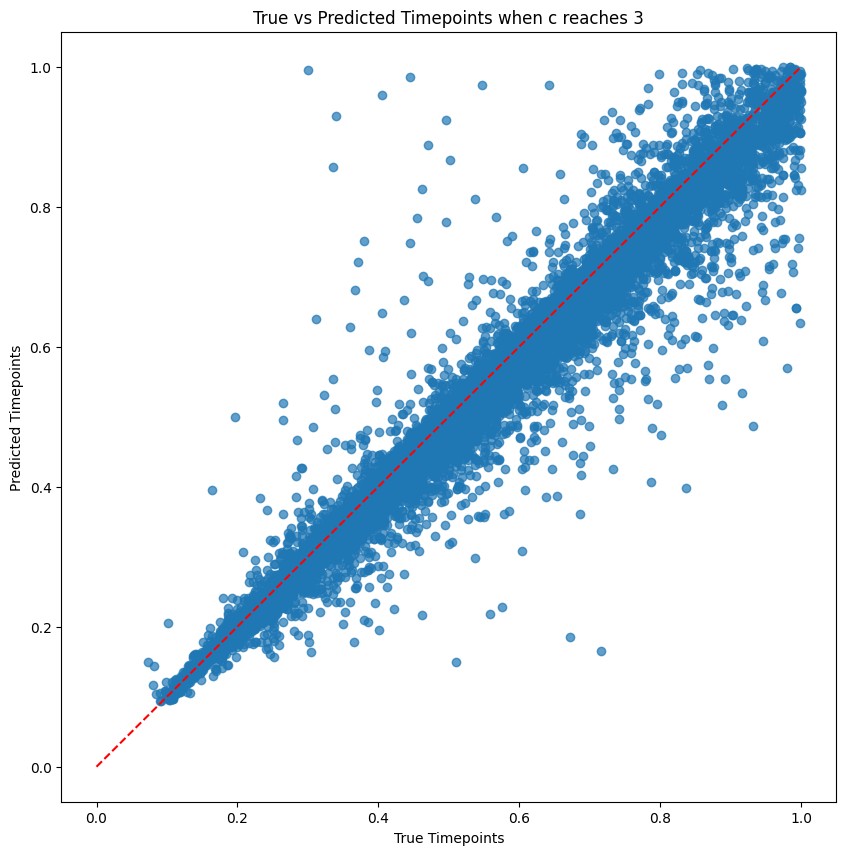

In [19]:
# Identify the timepoints when true value and predicted value of c reach 2
true_timepoints = []
pred_timepoints = []

for i in range(data_c_test.shape[0]):
    true_indices = np.where(data_c_test[i] >= 3)[0]
    pred_indices = np.where(predictions_c[i] >= 3)[0]
    
    if len(true_indices) > 0 and len(pred_indices) > 0:
        true_timepoints.append(t[true_indices[0]])
        pred_timepoints.append(t[pred_indices[0]])

# Convert lists to numpy arrays for plotting
true_timepoints = np.array(true_timepoints)
pred_timepoints = np.array(pred_timepoints)

# Plot the true timepoints against the predicted timepoints
plt.figure(figsize=(10, 10))
plt.scatter(true_timepoints, pred_timepoints, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--')  # Line y=x for reference
plt.xlabel('True Timepoints')
plt.ylabel('Predicted Timepoints')
plt.title('True vs Predicted Timepoints when c reaches 3')
plt.show()

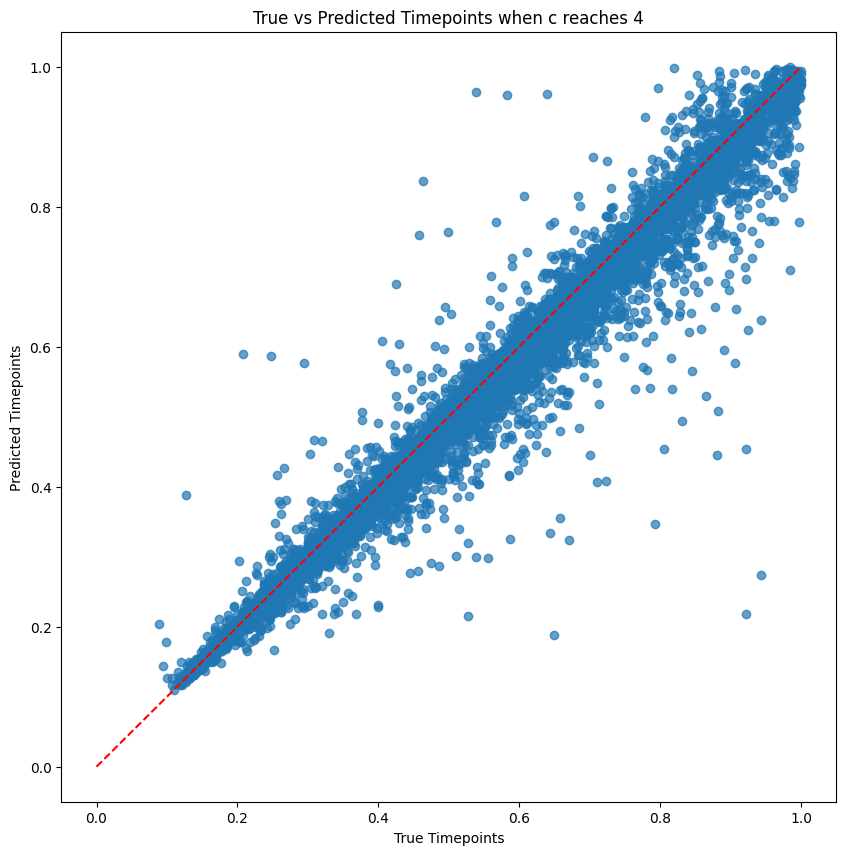

In [20]:
# Identify the timepoints when true value and predicted value of c reach 2
true_timepoints = []
pred_timepoints = []

for i in range(data_c_test.shape[0]):
    true_indices = np.where(data_c_test[i] >= 4)[0]
    pred_indices = np.where(predictions_c[i] >= 4)[0]
    
    if len(true_indices) > 0 and len(pred_indices) > 0:
        true_timepoints.append(t[true_indices[0]])
        pred_timepoints.append(t[pred_indices[0]])

# Convert lists to numpy arrays for plotting
true_timepoints = np.array(true_timepoints)
pred_timepoints = np.array(pred_timepoints)

# Plot the true timepoints against the predicted timepoints
plt.figure(figsize=(10, 10))
plt.scatter(true_timepoints, pred_timepoints, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--')  # Line y=x for reference
plt.xlabel('True Timepoints')
plt.ylabel('Predicted Timepoints')
plt.title('True vs Predicted Timepoints when c reaches 4')
plt.show()

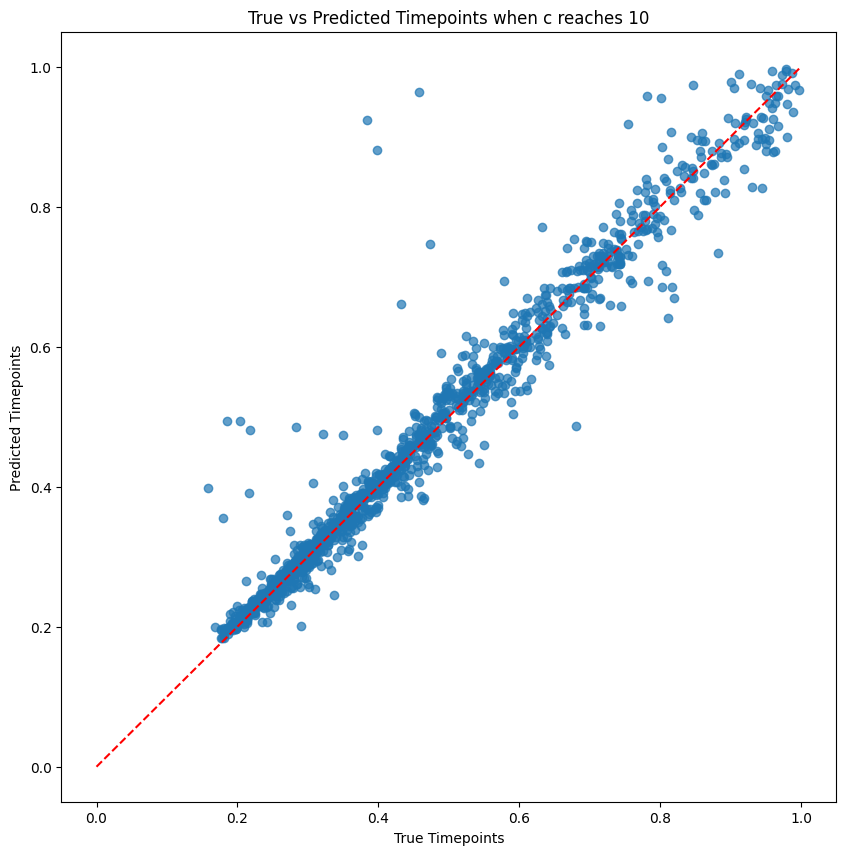

In [21]:
# Identify the timepoints when true value and predicted value of c reach 2
true_timepoints = []
pred_timepoints = []

for i in range(data_c_test.shape[0]):
    true_indices = np.where(data_c_test[i] >= 10)[0]
    pred_indices = np.where(predictions_c[i] >= 10)[0]
    
    if len(true_indices) > 0 and len(pred_indices) > 0:
        true_timepoints.append(t[true_indices[0]])
        pred_timepoints.append(t[pred_indices[0]])

# Convert lists to numpy arrays for plotting
true_timepoints = np.array(true_timepoints)
pred_timepoints = np.array(pred_timepoints)

# Plot the true timepoints against the predicted timepoints
plt.figure(figsize=(10, 10))
plt.scatter(true_timepoints, pred_timepoints, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--')  # Line y=x for reference
plt.xlabel('True Timepoints')
plt.ylabel('Predicted Timepoints')
plt.title('True vs Predicted Timepoints when c reaches 10')
plt.show()

41712
J_e: 0.7735814884018185
b_1: 1.7936540490396802
b_2: 26.19583099014192
h_e: 0.0
f_0: 0.20797135195801528
P_c: 0.20083029746754952
phi: 0.5514207351373956
ts_halton: 18.207612200161428
h_0: 5.923834183190308e-06


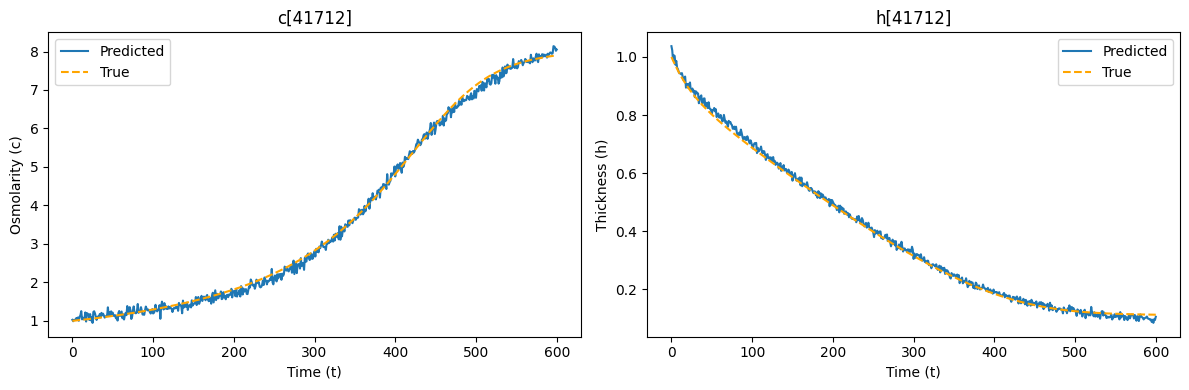

In [22]:
n = np.random.randint(0, len(data_h_test))
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]

print(n)
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")
pred_c = model_c.predict(data_i_test[n].reshape(1, -1))
pred_h = model_h.predict(data_i_test[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title('c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title('h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()


22438


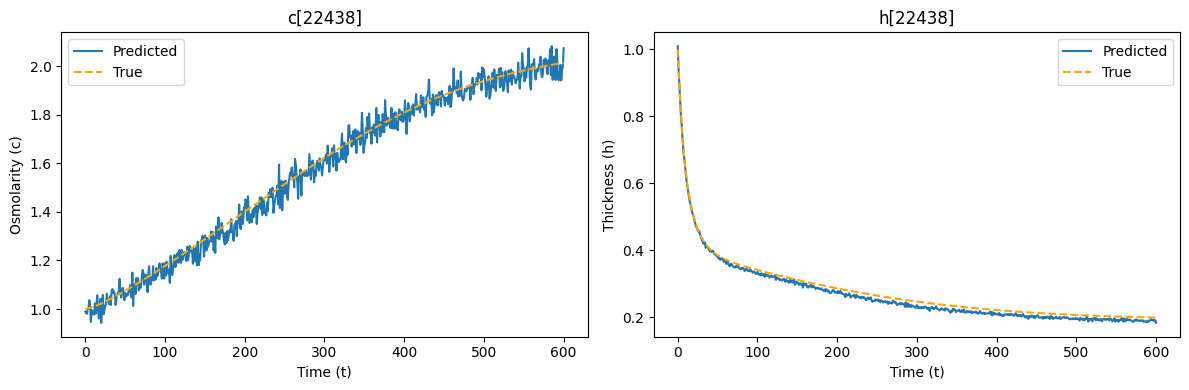

In [23]:
n = np.random.randint(0, len(data_h_test))
print(n)
pred_c = model_c.predict(data_i_test[n].reshape(1, -1))
pred_h = model_h.predict(data_i_test[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title('c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title('h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()


45749


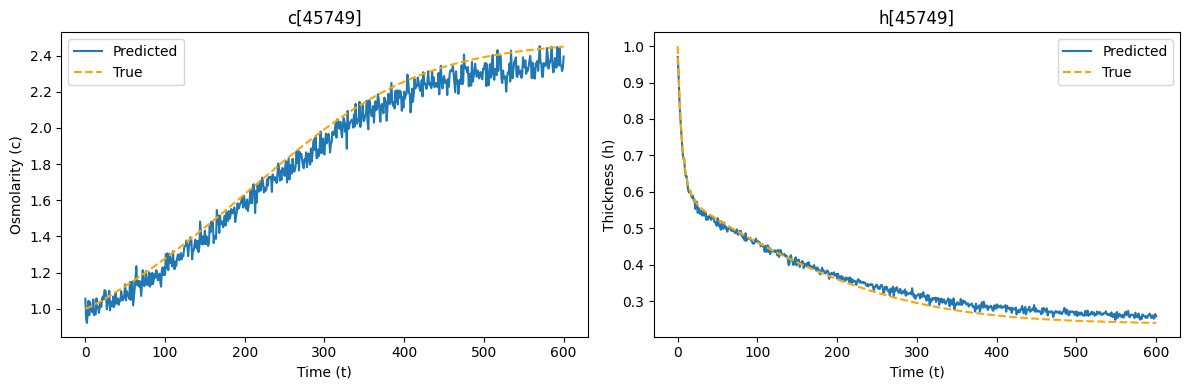

In [24]:
n = np.random.randint(0, len(data_h_test))
print(n)
pred_c = model_c.predict(data_i_test[n].reshape(1, -1))
pred_h = model_h.predict(data_i_test[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title('c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title('h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()


40305


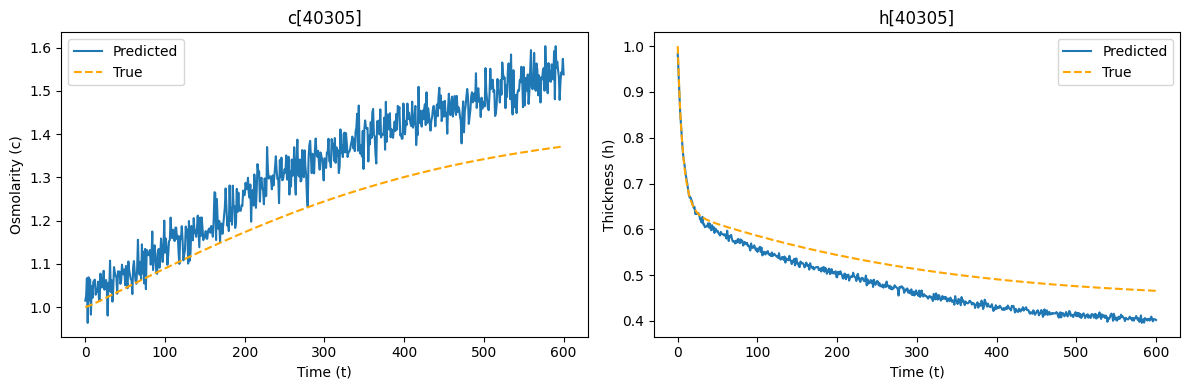

In [25]:
n = np.random.randint(0, len(data_h_test))
print(n)
pred_c = model_c.predict(data_i_test[n].reshape(1, -1))
pred_h = model_h.predict(data_i_test[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title('c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title('h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()


**Further inspection**

In [26]:
pred_c = model_c.predict(data_i_test)
error_c = np.sum((data_c_test - pred_c)**2, axis=1)/601
max_error_c = np.max(error_c)
print(max_error_c, np.mean(error_c))
max_error_index_c = np.argmax(error_c)
print("Index of max_error:", max_error_index_c)

24.693427997283795 0.0322474740180709
Index of max_error: 34553


In [27]:
pred_h = model_h.predict(data_i_test)
error_h = np.sum((data_h_test - pred_h)**2, axis=1)/601
max_error_h = np.max(error_h)
print(max_error_h, np.mean(error_h))
max_error_index_h = np.argmax(error_h)
print("Index of max_error:", max_error_index_h)

0.408549695564123 0.0006802054363007064
Index of max_error: 39492


34553


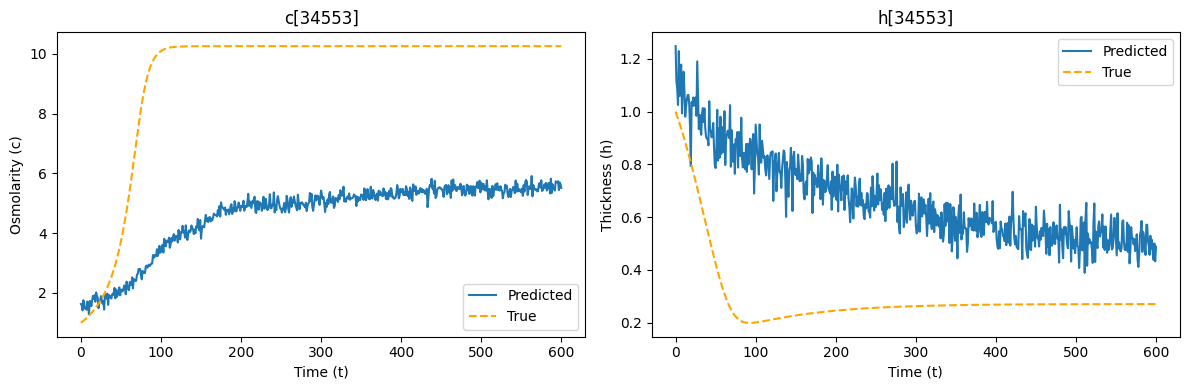

In [28]:
n = max_error_index_c
print(n)
pred_c = model_c.predict(data_i_test[n].reshape(1, -1))
pred_h = model_h.predict(data_i_test[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title('c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title('h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()


39492


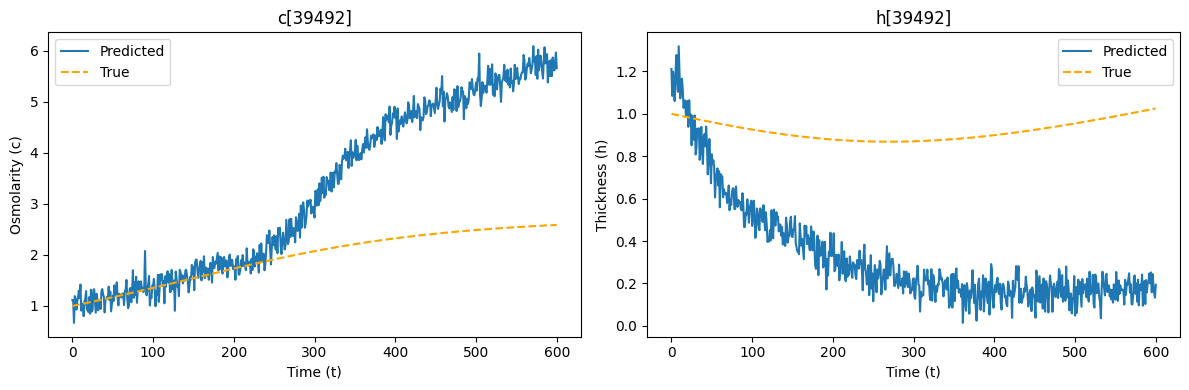

In [29]:
n = max_error_index_h
print(n)
pred_c = model_c.predict(data_i_test[n].reshape(1, -1))
pred_h = model_h.predict(data_i_test[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title('c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title('h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()


In [30]:
datastore_glob = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/PDE_1d_glob_center.jld2", 'r')
data_I_glob = np.array(np.array(datastore_glob["data_I_center"]))

data_c_glob = np.array(np.array(datastore_glob["data_c_center"]))
data_h_glob = np.array(np.array(datastore_glob["data_h_center"]))
para_glob = np.array(np.array(datastore_glob["para3"]))


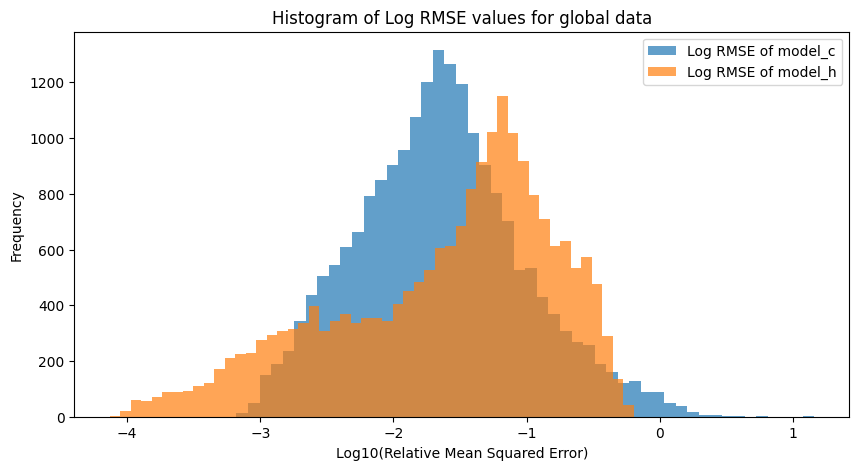

RMSE at c = 2: Mean = 0.39994028210639954, Std = 0.9970150589942932
RMSE at c = 3: Mean = 3.052539110183716, Std = 4.273288726806641
RMSE at c = 4: Mean = 8.341961860656738, Std = 7.937738418579102


In [31]:
# Prepare the test data
X_test_glob = data_I_glob.astype(np.float32)
y_test_c_glob = data_c_glob.astype(np.float32)
y_test_h_glob = data_h_glob.astype(np.float32)

# Use trained models to make predictions
predictions_c_glob = model_c.predict(X_test_glob)
predictions_h_glob = model_h.predict(X_test_glob)

# Compute Relative Mean Squared Error (RMSE) for model_c
rmse_c_glob = np.sum((predictions_c_glob - y_test_c_glob) ** 2, axis=1) / np.sum(y_test_c_glob ** 2, axis=1)
rmse_h_glob = np.sum((predictions_h_glob - y_test_h_glob) ** 2, axis=1) / np.sum(y_test_h_glob ** 2, axis=1)

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rmse_c_glob), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rmse_h_glob), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for global data')
plt.legend()
plt.show()

# Inspect performance for c = 2, 3, 4
special_points_glob = [2, 3, 4]
errors_at_special_points_glob = {str(point): [] for point in special_points_glob}

for i in range(y_test_c_glob.shape[0]):
    for point in special_points_glob:
        if np.max(y_test_c_glob[i]) >= point:
            index = np.argmin(np.abs(y_test_c_glob[i] - point))
            errors_at_special_points_glob[str(point)].append(np.abs((predictions_c_glob[i, index] - y_test_c_glob[i, index]) ** 2))

# Print analysis for special points
for point, errors in errors_at_special_points_glob.items():
    if errors:
        print(f"RMSE at c = {point}: Mean = {np.mean(errors)}, Std = {np.std(errors)}")
    else:
        print(f"No data points found for c = {point}")



4511


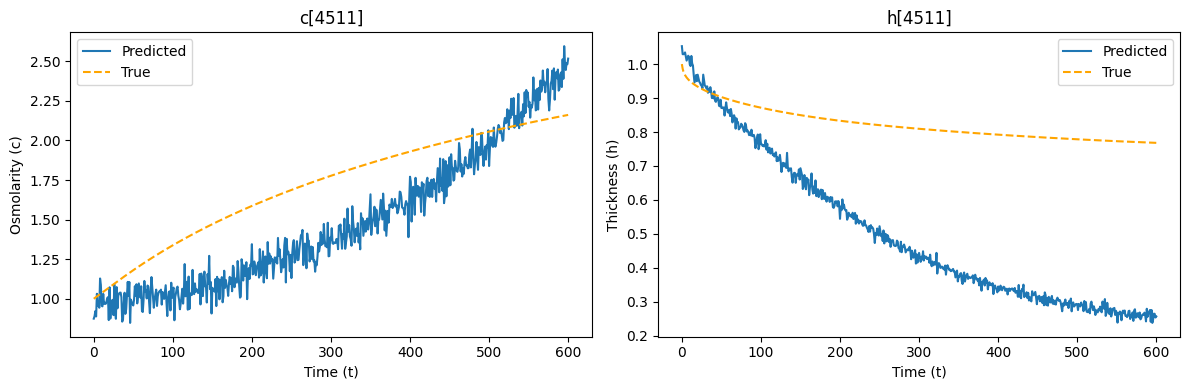

In [32]:
n = np.random.randint(0, len(data_h_glob))
print(n)
pred_c = model_c.predict(data_I_glob[n].reshape(1, -1))
pred_h = model_h.predict(data_I_glob[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c.T)
axs[0].plot(data_c_glob[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title('c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h.T)
axs[1].plot(data_h_glob[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title('h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()


In [33]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_ffn2"
# model_c.save(path)

In [34]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_ffn2"
# model_h.save(path)

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(losshistory_c.steps, np.log10(losshistory_c.loss_train), label='Training Loss in log10 scale')
plt.plot(losshistory_c.steps, np.log10(losshistory_c.loss_test), label='Testing Loss in log10 scale')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('log10 of Loss in c vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'losshistory_c' is not defined

<Figure size 800x500 with 0 Axes>

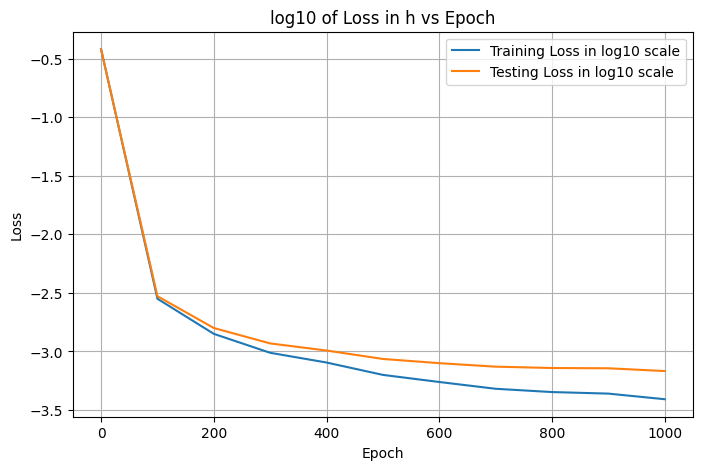

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(losshistory_h.steps, np.log10(losshistory_h.loss_train), label='Training Loss in log10 scale')
plt.plot(losshistory_h.steps, np.log10(losshistory_h.loss_test), label='Testing Loss in log10 scale')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('log10 of Loss in h vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

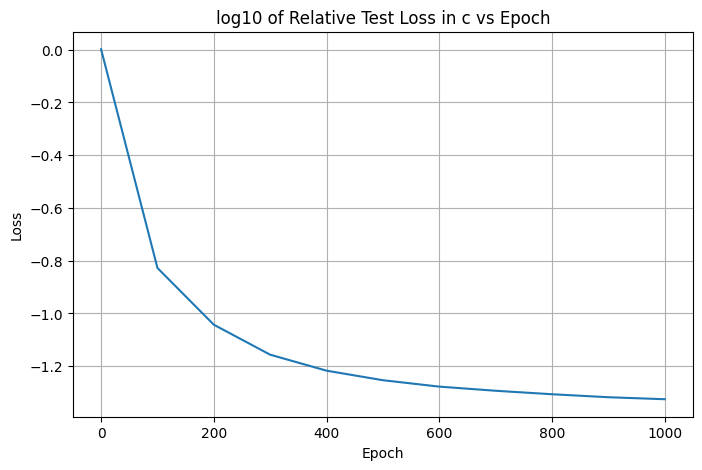

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(losshistory_h.steps, np.log10(losshistory_c.metrics_test), label='Relative Test Loss in log10 scale')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('log10 of Relative Test Loss in c vs Epoch')
# plt.legend()
plt.grid(True)
plt.show()

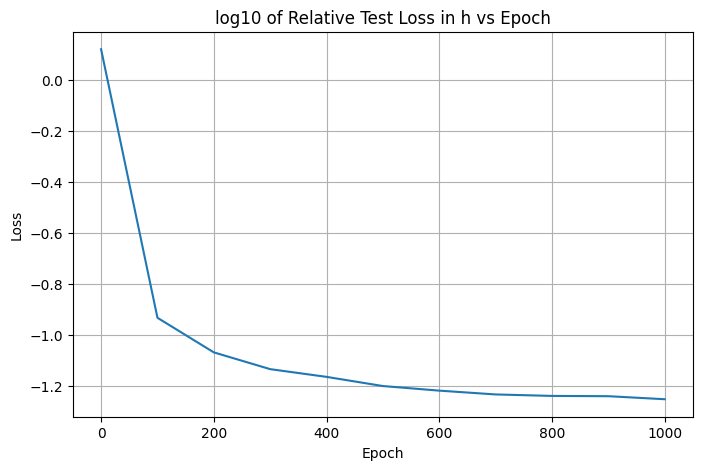

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(losshistory_h.steps, np.log10(losshistory_h.metrics_test), label='Relative Test Loss in log10 scale')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('log10 of Relative Test Loss in h vs Epoch')
# plt.legend()
plt.grid(True)
plt.show()

# Testing the model on experimental data

In [106]:
exprimental_data_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional.txt"
exprimental_data_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional_2.h5"
exprimental_data_nondimensional_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_nondimensional_2.h5"

In [107]:
with h5py.File(exprimental_data_path_h5, 'r') as h5f:
    t = h5f['t'][:]
    I = h5f['I'][:]
    p = h5f['p'][:]
    
I_scaled = np.array([row / row[0] for row in I], dtype=object)


In [108]:
def scale_time_arrays(t):
    """
    Linearly scale each time array so that:
      - the first value becomes 0
      - the value equal to ts becomes 1

    Parameters:
    - t: list or array of 1D numpy arrays (ragged)
    - ts_array: 1D array of float, ts for each instance

    Returns:
    - t_scaled: list of scaled time arrays with same structure
    """
    t_scaled = []

    for i in range(len(t)):
        t_i = t[i]
        t0 = t_i[0]
        t_end = t_i[-1]  # Assuming ts is the last value in the array

        t_scaled_i = (t_i - t0) / (t_end - t0)
        t_scaled.append(t_scaled_i)

    return np.array(t_scaled, dtype=object)


In [109]:
with h5py.File(exprimental_data_path_h5, 'r') as h5f:
    t_group = h5f['t']
    # Structured array access for 'ts'
    ts_array = h5f['p']['ts']
    id_array = h5f['p']['id']

t_scaled = scale_time_arrays(t)


In [110]:
from scipy.interpolate import PchipInterpolator

# Interpolate each row of t_scaled and I_scaled to length 601
n_points = 601
t_uniform = np.linspace(0, 1, n_points)

t_scaled_interp = []
I_scaled_interp = []

for t_row, I_row in zip(t_scaled, I_scaled):
    # Interpolators
    t_interp = t_uniform  # target x-axis
    I_interp_func = PchipInterpolator(t_row, I_row)
    I_interp = I_interp_func(t_interp)
    t_scaled_interp.append(t_interp)
    I_scaled_interp.append(I_interp)

t_scaled_interp = np.array(t_scaled_interp)
I_scaled_interp = np.array(I_scaled_interp)

In [ ]:
datastore = h5py.File(exprimental_data_nondimensional_path_h5, 'r')
data_I_calculated = np.array(datastore["calculated_I"])
data_h_calculated = np.array(datastore["calculated_h"])
data_f_calculated = np.array(datastore["calculated_f"])

data_c_caluculated = np.array(datastore["calculated_c"])
data_p_experimental_nondimensional = np.array(datastore["nondimensional_p"])

datastore.close()  # Close the read-only handle


<KeysViewHDF5 ['calculated_I', 'calculated_c', 'calculated_f', 'calculated_h', 'example_plot', 'nondimensional_p']>


Global RMSE for model_c: 0.81011975
Global RMSE for model_h: 0.08807366


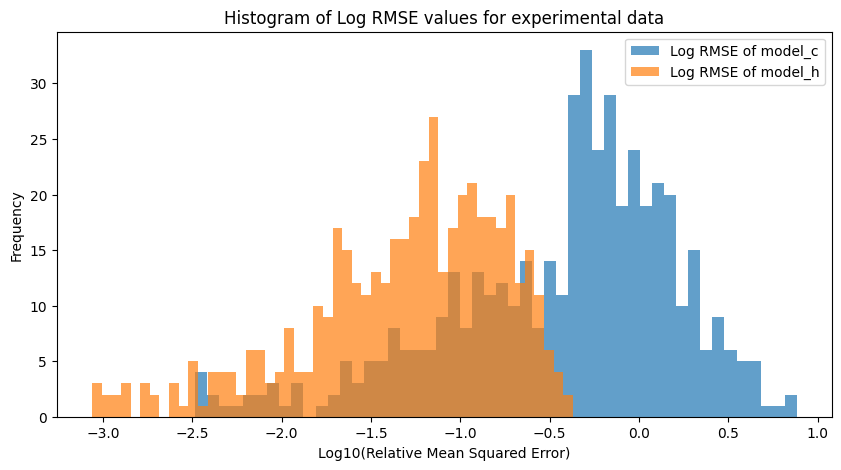

In [112]:
# Prepare the test data
X_test_expr = I_scaled_interp.astype(np.float32)
y_test_c_calculated = data_c_caluculated.astype(np.float32)
y_test_h_calculated = data_h_calculated.astype(np.float32)

# Use trained models to make predictions
predictions_c_calculated = model_c.predict(X_test_expr)
predictions_h_calculated = model_h.predict(X_test_expr)

# Compute Relative Mean Squared Error (RMSE) for model_c
rmse_c_calculated = np.sum((predictions_c_calculated - y_test_c_calculated) ** 2, axis=1) / np.sum(y_test_c_calculated ** 2, axis=1)
rmse_h_calculated = np.sum((predictions_h_calculated - y_test_h_calculated) ** 2, axis=1) / np.sum(y_test_h_calculated ** 2, axis=1)

print("Global RMSE for model_c:", np.mean(rmse_c_calculated))
print("Global RMSE for model_h:", np.mean(rmse_h_calculated))

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rmse_c_calculated), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rmse_h_calculated), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for experimental data')
plt.legend()
plt.show()

395


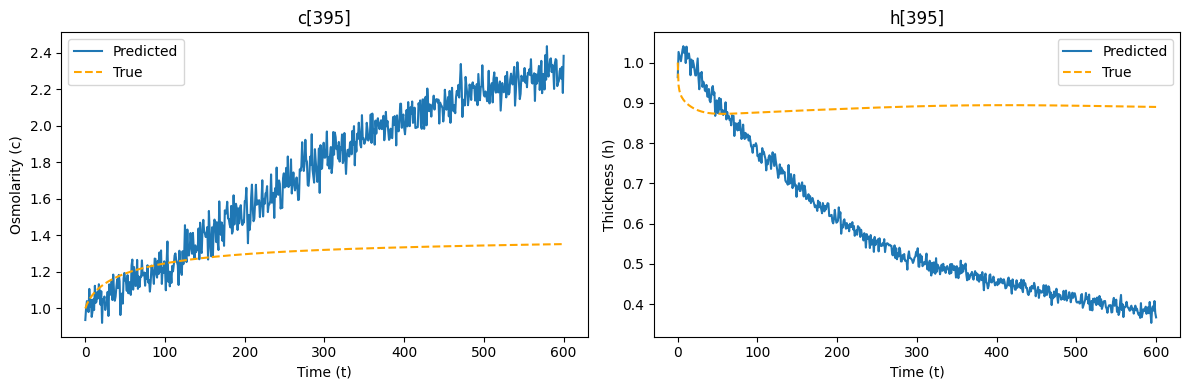

In [113]:
n = np.random.randint(0, len(X_test_expr))
print(n)
pred_c = model_c.predict(X_test_expr[n].reshape(1, -1))
pred_h = model_h.predict(X_test_expr[n].reshape(1, -1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c.T)
axs[0].plot(data_c_glob[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title('c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h.T)
axs[1].plot(data_h_glob[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title('h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()


In [114]:
# Calculate predictions for f from predictions_c_calculated and f_0
# f_0 is the fifth entry of data_p_experimental_nondimensional (index 4)
f_0_experimental = data_p_experimental_nondimensional[:, 4]  # shape: (num_samples,)

# predictions_c_calculated shape: (num_samples, 601)
# We want to multiply each row of predictions_c_calculated by the corresponding f_0
predictions_f_calculated = predictions_c_calculated * f_0_experimental[:, np.newaxis]


In [115]:
def calculate_I(h, f, phi, I_0=1.0):
    return I_0 * (1 - np.exp(-phi * h * f)) / (1 + f ** 2)

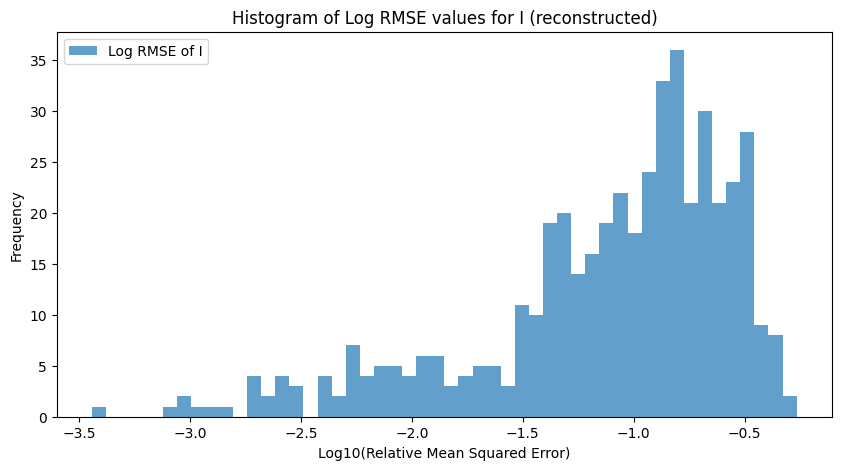

In [116]:
# Ensure phi is broadcastable to shape (num_samples, 601)
phi_expanded = data_p_experimental_nondimensional[:, 6][:, np.newaxis]  # shape: (num_samples, 1)

# Calculate I_pred using predictions_h_calculated and predictions_f_calculated
I_0_pred = 1/calculate_I(predictions_h_calculated[:,0].reshape(phi_expanded.shape), predictions_f_calculated[:,0].reshape(phi_expanded.shape), phi=phi_expanded)
I_pred = calculate_I(predictions_h_calculated, predictions_f_calculated, phi=phi_expanded, I_0=I_0_pred)

# Compute relative MSE for each sample
rel_mse_I = np.sum((I_pred - data_I_calculated) ** 2, axis=1) / np.sum(data_I_calculated ** 2, axis=1)

# Plot histogram of log10(relative MSE)
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rel_mse_I), bins=50, alpha=0.7, label='Log RMSE of I')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for I (reconstructed)')
plt.legend()
plt.show()

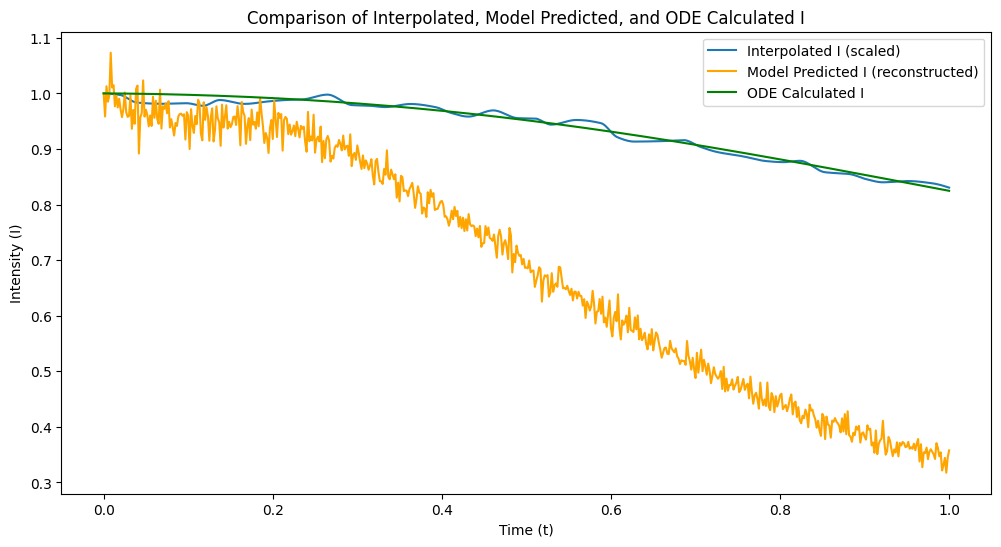

In [117]:
n = np.random.randint(0, len(I_scaled_interp))

plt.figure(figsize=(12, 6))
plt.plot(t_scaled_interp[n], I_scaled_interp[n], label='Interpolated I (scaled)')
plt.plot(t_scaled_interp[n], I_pred[n], color='orange', label='Model Predicted I (reconstructed)')
plt.plot(t_scaled_interp[n], data_I_calculated[n], color='green', label='ODE Calculated I')
plt.xlabel('Time (t)')
plt.ylabel('Intensity (I)')
plt.title('Comparison of Interpolated, Model Predicted, and ODE Calculated I')
plt.legend()
plt.show()

In [118]:
import os

# Path where plots will be stored
plot_dir_h = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/h_plots"
plot_dir_c = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/c_plots"
plot_dir_f = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/f_plots"
plot_dir_I = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FFN_plots/I_plots"
os.makedirs(plot_dir_h, exist_ok=True)  # Create the folder if it doesn't exist
os.makedirs(plot_dir_c, exist_ok=True)  # Create the folder if it doesn't exist
os.makedirs(plot_dir_I, exist_ok=True)  # Create the folder if it doesn't exist
os.makedirs(plot_dir_f, exist_ok=True)  # Create the folder if it doesn't exist

# Loop through all 467 samples
for idx in range(467):
    # Get data for this sample (already loaded in your variables)
    id = id_array[idx]
    t = t_scaled_interp[idx]
    I_exp = I_scaled_interp[idx]
    h_true = data_h_calculated[idx]
    c_true = data_c_caluculated[idx]
    f_true = data_f_calculated[idx]
    
    I_pred_n = I_pred[idx]
    h_pred = predictions_h_calculated[idx]
    c_pred = predictions_c_calculated[idx]
    f_pred = predictions_f_calculated[idx]
    
    I_ode = data_I_calculated[idx]
    
    fig1, ax1 = plt.subplots()
    ax1.plot(t, I_exp, label='Experimental I (scaled)')
    ax1.plot(t, I_pred_n, label='Model Predicted I (reconstructed)')
    ax1.plot(t, I_ode, color='green', label='ODE Calculated I')
    ax1.set_title(f'I for Sample {id}')
    ax1.set_xlabel('Time Index')
    ax1.set_ylabel('I')
    ax1.legend()
    fig1.tight_layout()
    fig1.savefig(f"{plot_dir_I}/I_{id}.png")
    plt.close(fig1)

    fig2, ax2 = plt.subplots()
    ax2.plot(t, h_true, label='ODE calculated h')
    ax2.plot(t, h_pred, label='Model Predicted h')
    ax2.set_title(f'h for Sample {id}')
    ax2.set_xlabel('Time Index')
    ax2.set_ylabel('h')
    ax2.legend()
    fig2.tight_layout()
    fig2.savefig(f"{plot_dir_h}/h_{id}.png")
    plt.close(fig2)
    
    fig3, ax3 = plt.subplots()
    ax3.plot(t, c_true, label='ODE calculated c')
    ax3.plot(t, c_pred, label='Model Predicted c')
    ax3.set_title(f'c for Sample {id}')
    ax3.set_xlabel('Time Index')
    ax3.set_ylabel('c')
    ax3.legend()
    fig3.tight_layout()
    fig3.savefig(f"{plot_dir_c}/c_{id}.png")
    plt.close(fig3)
    
    fig4, ax4 = plt.subplots()
    ax4.plot(t, f_true, label='ODE calculated f')
    ax4.plot(t, f_pred, label='Model Predicted f')
    ax4.set_title(f'f for Sample {id}')
    ax4.set_xlabel('Time Index')
    ax4.set_ylabel('f')
    ax4.legend()
    fig4.tight_layout()
    fig4.savefig(f"{plot_dir_f}/f_{id}.png")
    plt.close(fig4)
